# TimesFM 3.0 キャッチアップ — Colab

**目的:** TimesFM 3.0の主要APIを短時間で確認し、実際の分析に必要な検証パターンまで一通り実行します。

このノートブックで確認すること:

1. **Univariate zero-shot forecasting**
2. **Quantile forecast**と`forecast == p50`の意味
3. **Native multivariate forecasting** — 複数のtarget variateを共同予測
4. **Past-only / Past-and-future covariates**
5. 未来のcovariateを変えた**scenario forecast**
6. **Joint multivariate vs independent univariate**の比較
7. シンプルな**rolling backtest + seasonal-naive baseline**
8. TimesFM3の`Forecaster`と`Evaluator`の違い

> **重要:** 現在、TimesFM 3.0の事前学習済み重みには`TimesFM Non-Commercial License v1.0`が適用されます。  
> 非商用・非本番用途に制限されているため、業務やサービスへ適用する前に必ずライセンスを確認してください。

公式情報:
- GitHub: https://github.com/google-research/timesfm
- Model: https://huggingface.co/google/timesfm-3.0-pytorch
- PyPI: https://pypi.org/project/timesfm/

## 0. Colab runtime

推奨: **Runtime → Change runtime type → T4 GPU以上**

再現性を確保するため、現在のPyPIにあるTimesFM 3.0のバージョンを固定します。

In [8]:
!pip install -q "timesfm[torch]==3.0.1" matplotlib pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from timesfm3 import TimesFM3Forecaster, TimesFM3Evaluator, ModelConfig

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### Hugging Faceへのアクセス

`google/timesfm-3.0-pytorch`は、Hugging Face上でライセンス条件への同意が必要な場合があります。

1. ブラウザでモデルページの条件に同意
2. ColabのSecretsに`HF_TOKEN`を保存すると、次のセルで自動ログイン
3. すでにHugging Faceで認証済みなら省略可能

In [3]:
# Optional Hugging Face login for gated model access.
try:
    from google.colab import userdata
    from huggingface_hub import login

    hf_token = userdata.get("HF_TOKEN")
    login(token=hf_token, add_to_git_credential=False)
    print("Logged in to Hugging Face using Colab Secret: HF_TOKEN")
except Exception:
    print(
        "HF login skipped. If model download returns 401/403, "
        "accept the model terms on Hugging Face and set a Colab Secret named HF_TOKEN."
    )

HF login skipped. If model download returns 401/403, accept the model terms on Hugging Face and set a Colab Secret named HF_TOKEN.


## 1. Load the model

通常の推論やキャッチアップでは、`TimesFM3Forecaster`をメインAPIとして使います。

- input patch length: **32**
- output patch length: **64**
- quantiles: **0.1 ~ 0.9**
- 最大context: 現在の実装では**15,360**
- `forecast`は**median (p50)**

`device=None`の場合、CUDAがあれば自動的にGPUを使いますが、ここでは明示的に指定します。

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

forecaster = TimesFM3Forecaster.from_pretrained(
    "google/timesfm-3.0-pytorch",
    device=DEVICE,
    per_core_batch_size=8,
)

print("device:", forecaster.device)
print("max context:", forecaster.global_context)
print("input patch:", forecaster.config.input_patch_length)
print("output patch:", forecaster.config.output_patch_length)
print("quantiles:", forecaster.config.quantiles)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.32GB            

model.safetensors: downloading bytes:           |  0.00B            

device: cuda
max context: 15360
input patch: 32
output patch: 64
quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


## 2. Helper関数

In [5]:
QUANTILES = np.asarray(forecaster.config.quantiles, dtype=float)

def quantile_index(q: float) -> int:
    return int(np.argmin(np.abs(QUANTILES - q)))

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-8)
    smape = 200 * np.mean(np.abs(y_true - y_pred) / denom)
    return {"MAE": mae, "RMSE": rmse, "sMAPE(%)": smape}

def plot_univariate(context, output, actual=None, title=None, interval=(0.1, 0.9), filename=None):
    context = np.asarray(context)
    h = len(output.forecast)

    x_ctx = np.arange(len(context))
    x_h = np.arange(len(context), len(context) + h)

    plt.figure(figsize=(13, 4))
    plt.plot(x_ctx, context, label="context")
    plt.plot(x_h, output.forecast, label="TimesFM p50", linewidth=2)

    if actual is not None:
        plt.plot(x_h, actual, "--", label="actual")

    if output.quantiles is not None:
        lo = quantile_index(interval[0])
        hi = quantile_index(interval[1])
        plt.fill_between(
            x_h,
            output.quantiles[:, lo],
            output.quantiles[:, hi],
            alpha=0.2,
            label=f"p{int(interval[0]*100)}–p{int(interval[1]*100)}",
        )

    plt.axvline(len(context) - 1, linestyle=":", alpha=0.6)
    plt.title(title or "TimesFM 3.0 forecast")
    plt.legend()
    plt.grid(alpha=0.2)
    if filename:
        plt.savefig(filename, dpi=160, bbox_inches="tight")
    plt.show()

# Part A — 最もシンプルな使い方

## 3. Univariate: 長さの異なる複数の時系列をまとめて予測

`predict_batch`には、長さの異なる1D NumPy arrayをそのまま渡せます。

In [6]:
H = 48

def make_series(n, phase=0.0, trend=0.02, noise=0.12):
    t = np.arange(n, dtype=np.float32)
    y = (
        2.0
        + trend * t
        + 0.8 * np.sin(2 * np.pi * t / 24 + phase)
        + 0.35 * np.sin(2 * np.pi * t / 7)
        + rng.normal(0, noise, n)
    )
    return y.astype(np.float32)

full1 = make_series(256 + H, phase=0.0, trend=0.015)
full2 = make_series(180 + H, phase=0.8, trend=-0.004)

contexts = [full1[:-H], full2[:-H]]
actuals = [full1[-H:], full2[-H:]]

outputs = list(
    forecaster.predict_batch(
        contexts=contexts,
        horizon=H,
        return_quantiles=True,
        use_symmetric_averaging=False,
        make_positive=False,
    )
)

for i, out in enumerate(outputs):
    print(
        f"series {i}: context={contexts[i].shape}, "
        f"forecast={out.forecast.shape}, quantiles={out.quantiles.shape}"
    )

series 0: context=(256,), forecast=(48,), quantiles=(48, 9)
series 1: context=(180,), forecast=(48,), quantiles=(48, 9)


Series 0: {'MAE': np.float32(0.08821073), 'RMSE': np.float32(0.11381726), 'sMAPE(%)': np.float32(1.447527)}


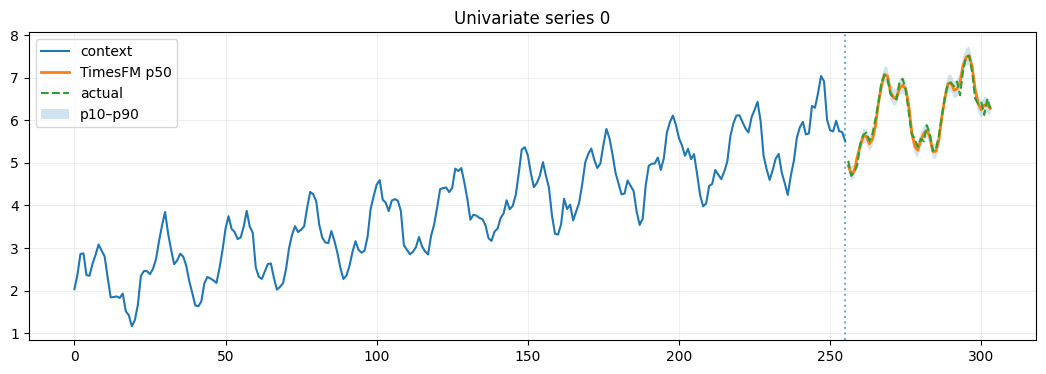

Series 1: {'MAE': np.float32(0.115495056), 'RMSE': np.float32(0.15161477), 'sMAPE(%)': np.float32(13.964981)}


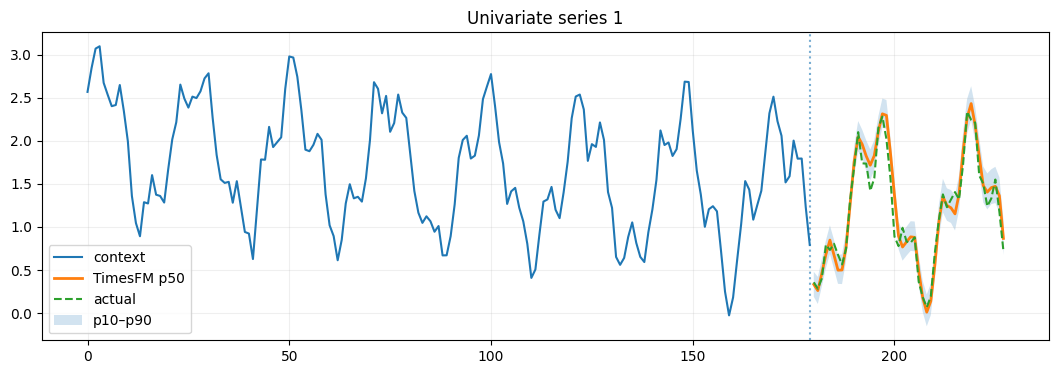

In [7]:
for i, (ctx, actual, out) in enumerate(zip(contexts, actuals, outputs)):
    print(f"Series {i}:", metrics(actual, out.forecast))
    plot_univariate(
        ctx,
        out,
        actual=actual,
        title=f"Univariate series {i}",
        filename=f"univariate-series-{i}.png",
    )

### 出力の意味

TimesFM 3.0の標準のquantileは`[0.1, ..., 0.9]`で、`forecast`はそのうちの**p50**です。

In [9]:
p50_idx = quantile_index(0.5)

print("quantiles:", QUANTILES)
print("p50 index:", p50_idx)

for i, out in enumerate(outputs):
    print(
        f"series {i} forecast == q50:",
        np.allclose(out.forecast, out.quantiles[:, p50_idx]),
    )

quantiles: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
p50 index: 4
series 0 forecast == q50: True
series 1 forecast == q50: True


# Part B — TimesFM 3.0の主要な変化

## 4. Native multivariate forecasting

3.0ではtarget自体を`(num_variates, context_length)`の形で入力し、**共同予測**できます。

ここでは、同じlatent processを共有する3本の時系列を作ります。

- `joint`: `(3, T)`をまとめて入力 → cross-variate informationを使用
- `independent`: 各rowを1D時系列として別々に予測

> `joint`が常に高精度という意味ではありません。  
> 重要なのは、3.0では**「複数の時系列を一緒に見るか」自体がモデリング上の選択肢**になったことです。

In [10]:
CTX = 256
H = 64
TOTAL = CTX + H
t = np.arange(TOTAL, dtype=np.float32)

latent = (
    0.015 * t
    + 1.2 * np.sin(2 * np.pi * t / 24)
    + 0.5 * np.sin(2 * np.pi * t / 7)
)

v0 = 20 + 3.0 * latent + rng.normal(0, 0.35, TOTAL)
v1 = 50 + 1.8 * latent + 0.25 * np.roll(v0, 1) + rng.normal(0, 0.45, TOTAL)
v2 = 10 - 1.2 * latent + 0.15 * np.roll(v1, 2) + rng.normal(0, 0.30, TOTAL)

target_full = np.vstack([v0, v1, v2]).astype(np.float32)
target_ctx = target_full[:, :CTX]
target_actual = target_full[:, CTX:]

joint_out = forecaster.predict(
    context=target_ctx,
    horizon=H,
    return_quantiles=True,
    use_symmetric_averaging=False,
    make_positive=False,
)

independent_outs = list(
    forecaster.predict_batch(
        contexts=[target_ctx[i] for i in range(target_ctx.shape[0])],
        horizon=H,
        return_quantiles=True,
        use_symmetric_averaging=False,
        make_positive=False,
    )
)
independent_forecast = np.stack([o.forecast for o in independent_outs])

print("target context:", target_ctx.shape)
print("joint forecast:", joint_out.forecast.shape)
print("joint quantiles:", joint_out.quantiles.shape)
print("independent forecast:", independent_forecast.shape)

target context: (3, 256)
joint forecast: (3, 64)
joint quantiles: (3, 64, 9)
independent forecast: (3, 64)


In [11]:
rows = []
for i in range(target_ctx.shape[0]):
    rows.append({
        "variate": i,
        "joint_MAE": metrics(target_actual[i], joint_out.forecast[i])["MAE"],
        "independent_MAE": metrics(target_actual[i], independent_forecast[i])["MAE"],
    })

pd.DataFrame(rows)

,variate,joint_MAE,independent_MAE
0,0,0.319287,0.332795
1,1,0.414138,0.432287
2,2,0.286407,0.299531


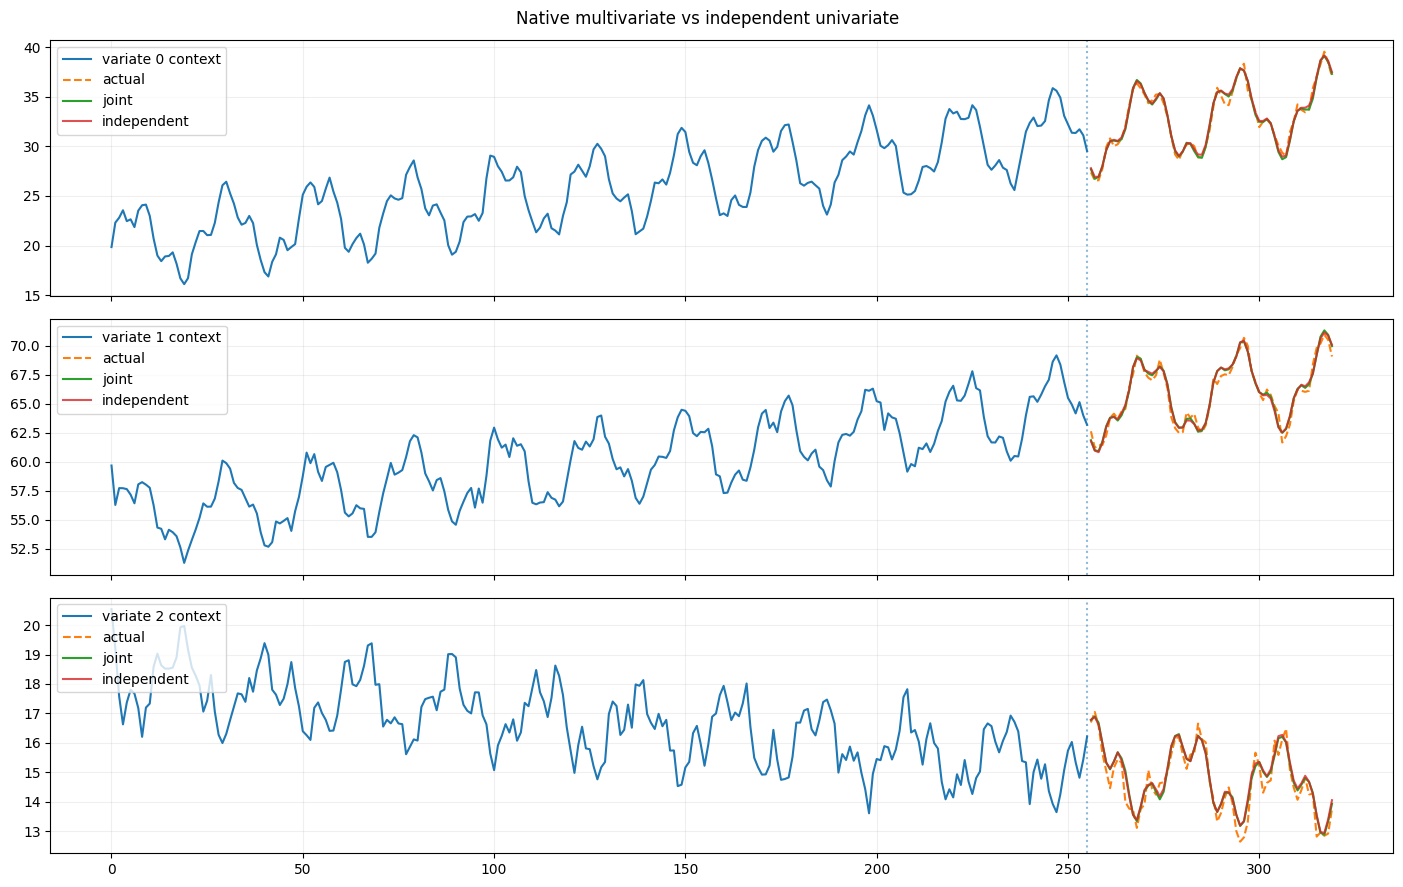

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

x_ctx = np.arange(CTX)
x_h = np.arange(CTX, CTX + H)

for i, ax in enumerate(axes):
    ax.plot(x_ctx, target_ctx[i], label=f"variate {i} context")
    ax.plot(x_h, target_actual[i], "--", label="actual")
    ax.plot(x_h, joint_out.forecast[i], label="joint")
    ax.plot(x_h, independent_forecast[i], label="independent", alpha=0.8)
    ax.axvline(CTX - 1, linestyle=":", alpha=0.5)
    ax.legend(loc="upper left")
    ax.grid(alpha=0.2)

plt.suptitle("Native multivariate vs independent univariate")
plt.tight_layout()
plt.savefig("joint-vs-independent.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Covariates: まずshapeを理解する

TimesFM 3.0で重要なshapeのルール:

| 入出力 | shape | 意味 |
|---|---:|---|
| target context | `(V, T)` | 予測対象となるV個のtargetの過去 |
| past-only covariates | `(C_po, T)` | 過去にだけ観測される補助変数 |
| past-future covariates | `(C_pf, T + H)` | 過去から未来のhorizonまで分かる変数 |
| forecast | `(V, H)` | targetごとのp50予測 |
| quantiles | `(V, H, 9)` | targetごとのp10〜p90 |

例:
- **past-only**: 現時点までに観測されたsensor、competitor signalなど
- **past-future**: カレンダー、予定済みのpromotion、確定した価格や運用計画など

## 6. 実践的なsynthetic example: Sales + Traffic + Promotion

ここでは次の構造を作ります。

- targets: `sales`, `traffic`
- past-only covariate: `competitor_signal`
- past-future covariates:
  - `promotion`
  - `weekend`

未来のpromotion scheduleは事前に分かっていると仮定します。

In [13]:
CTX = 256
H = 64
TOTAL = CTX + H
t = np.arange(TOTAL, dtype=np.float32)

weekend = ((t.astype(int) % 7) >= 5).astype(np.float32)

promotion = np.zeros(TOTAL, dtype=np.float32)
promotion[60:70] = 1
promotion[145:154] = 1
promotion[CTX + 10:CTX + 18] = 1
promotion[CTX + 38:CTX + 48] = 1

competitor_signal = (
    0.7 * np.sin(2 * np.pi * t / 31)
    + rng.normal(0, 0.15, TOTAL)
).astype(np.float32)

weekly = np.sin(2 * np.pi * t / 7)

sales = (
    100
    + 7 * weekly
    + 10 * weekend
    + 28 * promotion
    + 5 * competitor_signal
    + rng.normal(0, 2.0, TOTAL)
)

traffic = (
    220
    + 12 * weekly
    + 25 * weekend
    + 55 * promotion
    + 8 * competitor_signal
    + rng.normal(0, 4.0, TOTAL)
)

targets_full = np.vstack([sales, traffic]).astype(np.float32)

target_context = targets_full[:, :CTX]
actual_future = targets_full[:, CTX:]

past_only_cov = competitor_signal[:CTX][None, :]
past_future_cov = np.vstack([promotion, weekend]).astype(np.float32)

print("target:", target_context.shape)
print("past-only:", past_only_cov.shape)
print("past-future:", past_future_cov.shape)

target: (2, 256)
past-only: (1, 256)
past-future: (2, 320)


In [14]:
out_with_cov = forecaster.predict(
    context=target_context,
    horizon=H,
    past_only_covariates=past_only_cov,
    past_future_covariates=past_future_cov,
    return_quantiles=True,
    use_symmetric_averaging=False,
    make_positive=True,
)

out_without_cov = forecaster.predict(
    context=target_context,
    horizon=H,
    return_quantiles=True,
    use_symmetric_averaging=False,
    make_positive=True,
)

comparison = []
for i, name in enumerate(["sales", "traffic"]):
    comparison.append({
        "target": name,
        "MAE_with_covariates": metrics(actual_future[i], out_with_cov.forecast[i])["MAE"],
        "MAE_without_covariates": metrics(actual_future[i], out_without_cov.forecast[i])["MAE"],
    })

pd.DataFrame(comparison)

,target,MAE_with_covariates,MAE_without_covariates
0,sales,2.337771,8.745473
1,traffic,4.999482,17.582790


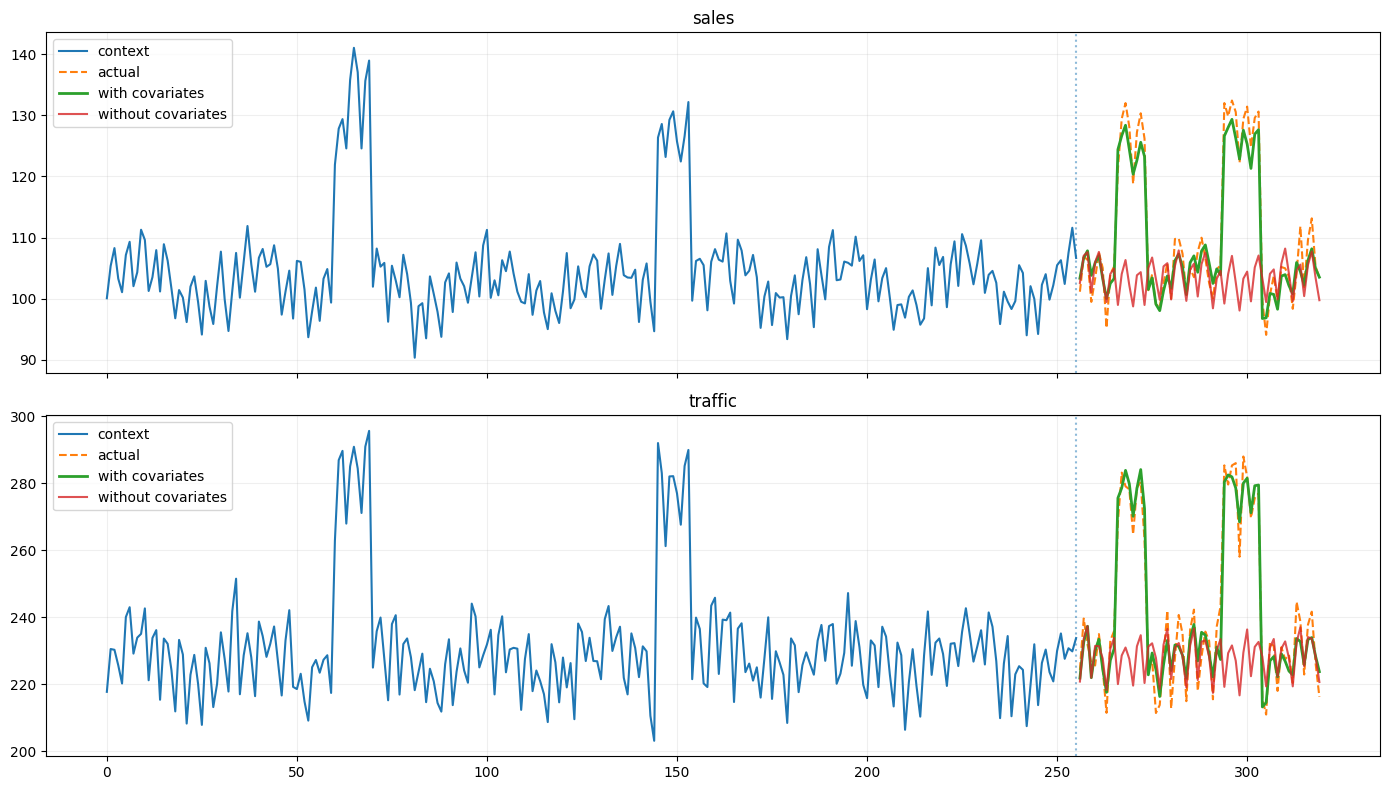

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x_ctx = np.arange(CTX)
x_h = np.arange(CTX, CTX + H)

for i, name in enumerate(["sales", "traffic"]):
    ax = axes[i]
    ax.plot(x_ctx, target_context[i], label="context")
    ax.plot(x_h, actual_future[i], "--", label="actual")
    ax.plot(x_h, out_with_cov.forecast[i], label="with covariates", linewidth=2)
    ax.plot(x_h, out_without_cov.forecast[i], label="without covariates", alpha=0.8)
    ax.axvline(CTX - 1, linestyle=":", alpha=0.5)
    ax.set_title(name)
    ax.legend(loc="upper left")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("with-vs-without-covariates.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Scenario forecast: 「未来のpromotionをなくしたら？」

`past_future_covariates`の未来部分だけを変え、二つの条件付き予測を比較できます。

- Scenario A: 予定されたpromotionを維持
- Scenario B: 未来のpromotion = 0

### 注意

この差は**causal effectの推定値ではありません。**

`forecast(X_future = promo)`と`forecast(X_future = no_promo)`の差は、モデルによる**conditional scenario forecast**です。  
promotionを実施したときの因果効果を主張するには、別途causal identificationの仮定や設計が必要です。

In [16]:
pfc_no_future_promo = past_future_cov.copy()
pfc_no_future_promo[0, CTX:] = 0.0

out_no_future_promo = forecaster.predict(
    context=target_context,
    horizon=H,
    past_only_covariates=past_only_cov,
    past_future_covariates=pfc_no_future_promo,
    return_quantiles=True,
    use_symmetric_averaging=False,
    make_positive=True,
)

scenario_delta = out_with_cov.forecast - out_no_future_promo.forecast

print("Average forecast difference over horizon")
print("sales:", scenario_delta[0].mean())
print("traffic:", scenario_delta[1].mean())

Average forecast difference over horizon
sales: 6.712637
traffic: 14.290438


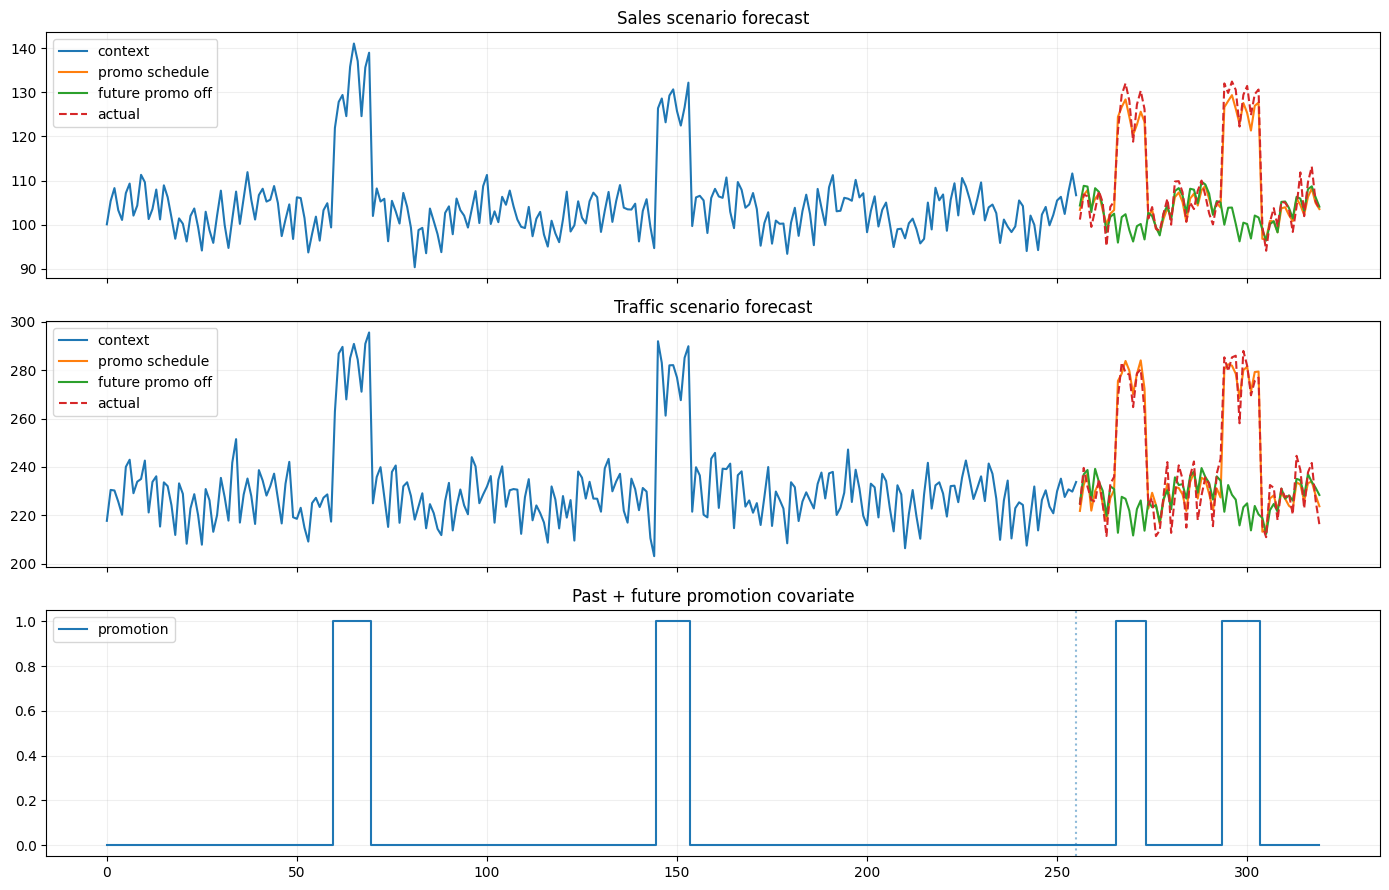

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

x_h = np.arange(CTX, CTX + H)

axes[0].plot(x_ctx, target_context[0], label="context")
axes[0].plot(x_h, out_with_cov.forecast[0], label="promo schedule")
axes[0].plot(x_h, out_no_future_promo.forecast[0], label="future promo off")
axes[0].plot(x_h, actual_future[0], "--", label="actual")
axes[0].set_title("Sales scenario forecast")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(x_ctx, target_context[1], label="context")
axes[1].plot(x_h, out_with_cov.forecast[1], label="promo schedule")
axes[1].plot(x_h, out_no_future_promo.forecast[1], label="future promo off")
axes[1].plot(x_h, actual_future[1], "--", label="actual")
axes[1].set_title("Traffic scenario forecast")
axes[1].legend()
axes[1].grid(alpha=0.2)

axes[2].step(
    np.arange(TOTAL),
    promotion,
    where="mid",
    label="promotion",
)
axes[2].axvline(CTX - 1, linestyle=":", alpha=0.5)
axes[2].set_title("Past + future promotion covariate")
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig("promotion-scenario.png", dpi=160, bbox_inches="tight")
plt.show()

# Part C — 実際の検証ルーチン

## 8. Rolling backtest

Foundation modelでも、**baselineと比較しなければ意味がありません。**

ここでは最もシンプルに、

- TimesFM p50
- seasonal naive

を複数のcut pointで比較します。

In [29]:
def seasonal_naive(context, horizon, period):
    context = np.asarray(context)
    pattern = context[-period:]
    repeats = int(np.ceil(horizon / period))
    return np.tile(pattern, repeats)[:horizon]

def rolling_backtest(
    model,
    series,
    context_length=192,
    horizon=24,
    n_windows=5,
    step=24,
    seasonal_period=24,
):
    series = np.asarray(series, dtype=np.float32)

    last_cut = len(series) - horizon
    cuts = [last_cut - step * i for i in range(n_windows)][::-1]

    contexts = []
    actuals = []

    for cut in cuts:
        if cut - context_length < 0:
            raise ValueError("series is too short for the requested backtest.")
        contexts.append(series[cut - context_length:cut])
        actuals.append(series[cut:cut + horizon])

    tfm_outputs = list(
        model.predict_batch(
            contexts=contexts,
            horizon=horizon,
            return_quantiles=True,
            use_symmetric_averaging=False,
            make_positive=False,
        )
    )

    rows = []
    for window, (cut, ctx, actual, out) in enumerate(
        zip(cuts, contexts, actuals, tfm_outputs)
    ):
        naive = seasonal_naive(ctx, horizon, seasonal_period)

        tfm_m = metrics(actual, out.forecast)
        naive_m = metrics(actual, naive)

        rows.append({
            "window": window,
            "cut": cut,
            "TimesFM_MAE": tfm_m["MAE"],
            "SeasonalNaive_MAE": naive_m["MAE"],
            "TimesFM_sMAPE": tfm_m["sMAPE(%)"],
            "SeasonalNaive_sMAPE": naive_m["sMAPE(%)"],
        })

    return pd.DataFrame(rows), tfm_outputs, actuals

long_series = make_series(
    700,
    phase=0.3,
    trend=0.008,
    noise=0.18,
)

bt, bt_outputs, bt_actuals = rolling_backtest(
    forecaster,
    long_series,
    context_length=256,
    horizon=48,
    n_windows=5,
    step=48,
    seasonal_period=24,
)

bt

,window,cut,TimesFM_MAE,SeasonalNaive_MAE,TimesFM_sMAPE,SeasonalNaive_sMAPE
0,0,460,0.173869,0.430452,2.919494,7.533182
1,1,508,0.146666,0.444576,2.407919,7.334068
2,2,556,0.154600,0.422189,2.385732,6.657329
3,3,604,0.158244,0.442407,2.292255,6.489016
4,4,652,0.161289,0.493452,2.164643,6.893372


In [19]:
bt[[
    "TimesFM_MAE",
    "SeasonalNaive_MAE",
    "TimesFM_sMAPE",
    "SeasonalNaive_sMAPE",
]].mean().to_frame("mean")

,mean
TimesFM_MAE,0.156712
SeasonalNaive_MAE,0.451678
TimesFM_sMAPE,2.405938
SeasonalNaive_sMAPE,7.034830


## 9. Quantile calibration sanity check

p10〜p90 intervalなら、理想的には実測値の約80%が区間内に入ると期待できます。

ただし、少数サンプルの単一backtestだけでcalibrationを判断してはいけません。  
複数のseries × 複数のforecast originについて集計します。

In [20]:
def interval_coverage(actual, quantiles, lower_q=0.1, upper_q=0.9):
    lo = quantiles[..., quantile_index(lower_q)]
    hi = quantiles[..., quantile_index(upper_q)]
    actual = np.asarray(actual)
    return np.mean((actual >= lo) & (actual <= hi))

coverages = []
for window, (actual, out) in enumerate(zip(bt_actuals, bt_outputs)):
    coverage = interval_coverage(actual, out.quantiles, 0.1, 0.9)
    coverages.append(coverage)
    print(f"window {window} p10-p90 coverage: {coverage:.3f}")

print("mean coverage:", np.mean(coverages))

window 0 p10-p90 coverage: 0.750
window 1 p10-p90 coverage: 0.792
window 2 p10-p90 coverage: 0.958
window 3 p10-p90 coverage: 0.833
window 4 p10-p90 coverage: 0.854
mean coverage: 0.8375


# Part D — オプションとgotchas

## 10. `TimesFM3Forecaster` vs `TimesFM3Evaluator`

公式例では`TimesFM3Evaluator`が使われています。

### Forecaster

通常の推論wrapperです。

既定値:
- `return_quantiles=False`
- `use_symmetric_averaging=False`
- `make_positive=False`
- `sort_quantiles=True`

### Evaluator

公式benchmark evaluation用のsubclassです。

既定値:
- `return_quantiles=True`
- `use_symmetric_averaging=True`
- `make_positive=True`
- `sort_quantiles=True`
- 高次元のmultivariate入力を最大32 variate単位で自動chunk
- `univariate=True`でchannelを独立seriesとして評価可能

つまり、**通常の実験コードではForecasterの方が条件を明示しやすく**、  
**benchmarkの再現にはEvaluatorが便利**です。

特に`Evaluator`の`make_positive=True`は、過去がすべてnon-negativeのtargetについて負のforecastを0にclampするため、結果を解釈するときに注意が必要です。

In [21]:
# Benchmark-style APIを使う場合は次の形です。
# 同じnotebookで二つのモデルを同時にGPUへ載せるとメモリを多く使うため、
# ここでは実際に生成せず、例だけを残します。

# eval_config = ModelConfig(
#     checkpoint_path="google/timesfm-3.0-pytorch",
#     per_core_batch_size=8,
#     device=DEVICE,
# )
# evaluator = TimesFM3Evaluator(eval_config)
#
# outputs = list(
#     evaluator.predict_batch(
#         contexts=[...],
#         horizon=64,
#         # Evaluator defaults:
#         # return_quantiles=True,
#         # use_symmetric_averaging=True,
#         # make_positive=True,
#     )
# )

## 11. Long horizon > 64

モデルのoutput patchが64でも、horizonが64に制限されるわけではありません。

現在のwrapperは、要求されたhorizonを内部で64の倍数に拡張し、必要な長さだけを返します。  
そのため、128、160、512といったlong-horizon forecastも呼び出せます。

In [22]:
LONG_H = 160
long_ctx = make_series(384, phase=0.2, trend=0.004)

long_out = forecaster.predict(
    context=long_ctx,
    horizon=LONG_H,
    return_quantiles=True,
)

print("forecast:", long_out.forecast.shape)
print("quantiles:", long_out.quantiles.shape)

forecast: (160,)
quantiles: (160, 9)


## 12. NaN handlingを確認

現在のForecaster wrapperは、

- すべてのtarget variateでleading time pointsがNaNなら、先頭部分を削除
- 内部のNaNはlinear interpolationで補間

します。

それでも実務ではモデル任せにせず、**欠損値の処理方針を明示的に管理**する方が安全です。

In [23]:
nan_ctx = make_series(200).copy()
nan_ctx[:10] = np.nan
nan_ctx[70:75] = np.nan

nan_out = forecaster.predict(
    context=nan_ctx,
    horizon=24,
    return_quantiles=True,
)

print("forecast shape:", nan_out.forecast.shape)
print("contains NaN:", np.isnan(nan_out.forecast).any())

forecast shape: (24,)
contains NaN: False


# 13. Catch-up checklist

TimesFM 3.0を素早く評価するなら、次の順序で十分です。

1. **Univariate zero-shot**で基本性能を確認
2. `context_length`を128 / 512 / 2048などに変えて感度を確認
3. 関連seriesがあるなら**joint multivariate vs independent**を比較
4. 未来に確実に分かる変数があるなら**past-future covariate**を追加
5. covariateの**ablation**: with / withoutを比較
6. seasonal naive / ETS / 既存production modelと**rolling backtest**
7. p10〜p90の**coverage**を確認
8. 必要な場合だけ`symmetric_averaging`、`make_positive`などのinference optionを検証

### 重要な解釈

TimesFM 3.0のキャッチアップで重要なのは、単に「TimesFM 2.5よりforecastが良くなった」という話ではありません。

**2.5までのunivariate-first foundation forecastingから、  
3.0ではtarget variatesとcovariatesを一つのモデル入力内で一緒に扱う方向へ拡張されました。**

特に実務では、

> `historical target` + `related series` + `known future plan/calendar`

をzero-shotでまとめて入力できる点が大きな変化です。